# 6. Choosing the truncation degree

A sharp-edged starspot contains structure at every spherical-harmonic
degree, so in principle a perfect surface model needs infinitely many
coefficients. The observable signals are far more forgiving: the
astrometric and photometric responses fall off quickly with degree, so a
model truncated at L of about 20 to 30 reproduces the signals of a much
sharper surface essentially exactly. This notebook makes that concrete,
and shows why fitting high-order terms buys nothing.

We build a "worst case" star: many spots with hard edges (no smoothing
taper), represented at L = 40.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm
from jittermap.plotting.render import build_projection_grid, render_surface_fast
from jittermap.plotting.panels import render_panel, normalize_map
GRID = build_projection_grid(n_grid=200)
X, Y, Z, THETA, PHI, MASK = GRID

def show_star(ax, coeffs, l_max, beta, title="", t=0.0):
    m = render_surface_fast(coeffs, l_max, beta, THETA, PHI, MASK, X, Y, Z, t=t)
    render_panel(ax, normalize_map(m), title, beta)
    ax.set_xticks([]); ax.set_yticks([])


In [2]:
L_REF, N, BETA = 40, 200, 0.6
rng = np.random.default_rng(7)
spots, f = [], 0.0
while f < 0.04 and len(spots) < 40:
    r = min(0.03 * rng.lognormal(0.0, 0.8), 0.3)
    spots.append((rng.uniform(5, 40) * rng.choice([-1.0, 1.0]),
                  rng.uniform(0, 360), jm.rfrac_to_deg(r)))
    f += r * r
spots += [(25, 310, jm.rfrac_to_deg(0.09)), (-15, 40, jm.rfrac_to_deg(0.07))]
star = jm.multispot_surface(spots, L_REF, sigma_taper=False)
print(len(spots), "sharp-edged spots")

35 sharp-edged spots


## Truncation visibly changes the surface

Zeroing all coefficients above a degree L is exactly what a lower-degree
model would represent. Side by side, the truncated surfaces are visibly
smoother and start to ring around the sharp spot edges:

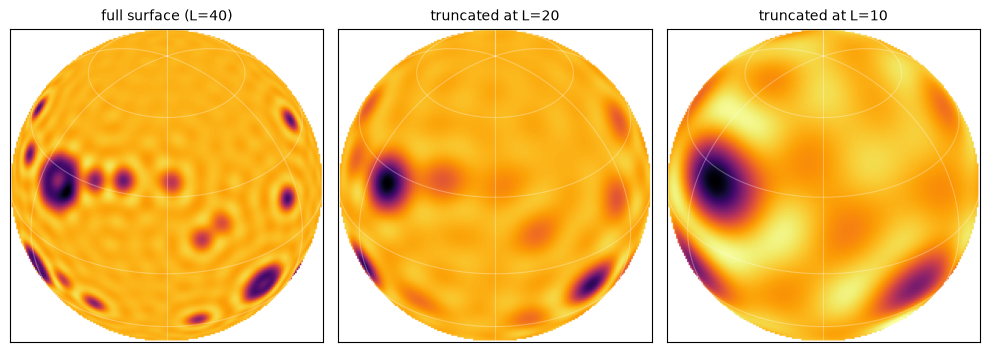

In [3]:
def truncate(s, Lt):
    s_t = s.copy()
    s_t[(Lt + 1) ** 2:] = 0
    return s_t

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, Lt in zip(axes, [40, 20, 10]):
    show_star(ax, truncate(star, Lt), L_REF, BETA,
              "full surface (L=40)" if Lt == 40 else f"truncated at L={Lt}")
plt.tight_layout()

## The signals barely change

Simulate the three channels from the full L = 40 surface and from a
truncation at L = 15, and overlay them:

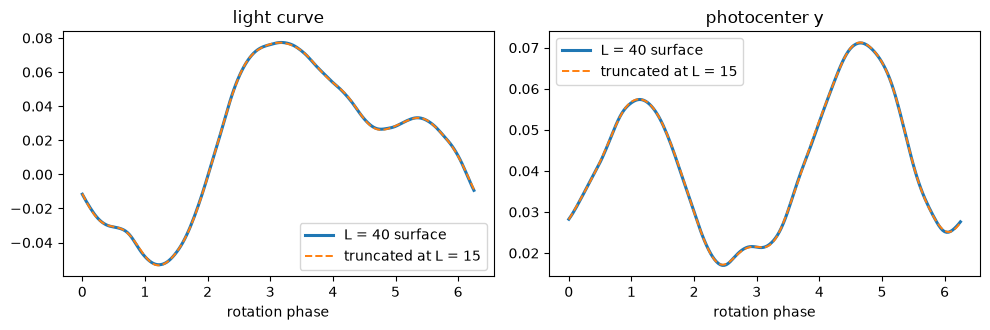

In [4]:
times = np.linspace(0, 2 * np.pi, N, endpoint=False)
fm = jm.ForwardModel(times, l_max=L_REF)
y_ref = fm.observe(star, BETA, channels="xyp", stacked=False)
y_15 = fm.observe(truncate(star, 15), BETA, channels="xyp", stacked=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(times, y_ref["p"], lw=2.2, label="L = 40 surface")
axes[0].plot(times, y_15["p"], "--", lw=1.4, label="truncated at L = 15")
axes[0].set_title("light curve"); axes[0].legend()
axes[1].plot(times, y_ref["y"], lw=2.2, label="L = 40 surface")
axes[1].plot(times, y_15["y"], "--", lw=1.4, label="truncated at L = 15")
axes[1].set_title("photocenter y"); axes[1].legend()
for ax in axes:
    ax.set_xlabel("rotation phase")
plt.tight_layout()

The curves lie on top of each other. Quantifying the residual for every
truncation degree, per channel, against realistic noise levels:

L = 10: worst-channel error 3.0e-02
L = 20: worst-channel error 4.3e-03
L = 30: worst-channel error 1.1e-03


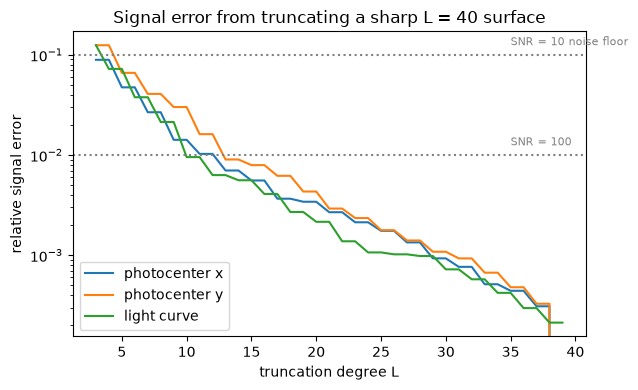

In [5]:
L_grid = range(3, L_REF)
errs = {c: [] for c in "xyp"}
for Lt in L_grid:
    y_t = fm.observe(truncate(star, Lt), BETA, channels="xyp", stacked=False)
    for c in "xyp":
        errs[c].append(np.sqrt(np.mean((y_t[c] - y_ref[c]) ** 2))
                       / np.std(y_ref[c]))

plt.figure(figsize=(6.5, 4))
for c, label in [("x", "photocenter x"), ("y", "photocenter y"),
                 ("p", "light curve")]:
    plt.semilogy(list(L_grid), errs[c], label=label)
plt.axhline(1e-1, color="gray", ls=":")
plt.text(35, 1.25e-1, "SNR = 10 noise floor", fontsize=8, color="gray")
plt.axhline(1e-2, color="gray", ls=":")
plt.text(35, 1.25e-2, "SNR = 100", fontsize=8, color="gray")
plt.xlabel("truncation degree L")
plt.ylabel("relative signal error")
plt.title("Signal error from truncating a sharp L = 40 surface")
plt.legend(); plt.tight_layout()

for Lt in [10, 20, 30]:
    i = list(L_grid).index(Lt)
    print(f"L = {Lt:2d}: worst-channel error "
          f"{max(errs[c][i] for c in 'xyp'):.1e}")

Reading off the curve: a truncation at L = 10 is already below the noise
of an SNR = 10 measurement, L = 20 is below SNR of a few hundred, and
L = 30 is at the 0.1 percent level. Since even optimistic future
astrometry sits at SNR of order 10 to 100 (paper Section 3), **fitting
coefficients beyond L of about 20 to 30 adds parameters that the data
cannot see.**

## Per-degree contributions to the signal

Each degree contributes to the signal in proportion to its kernel weight
times its surface power, and both fall off with degree. Plotting each
degree's contribution to the photocenter and flux signals:

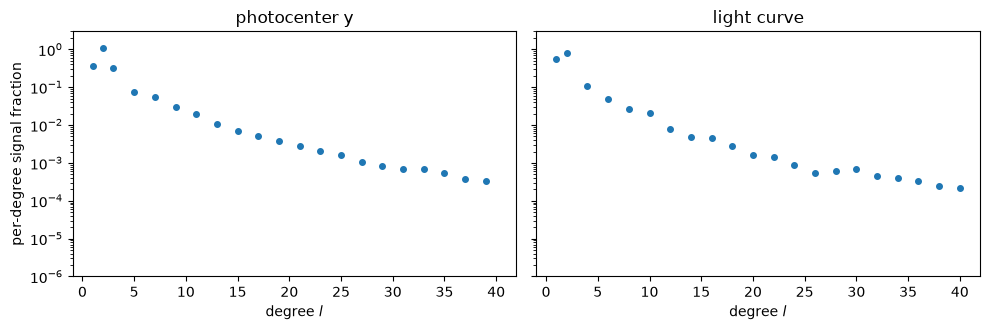

In [6]:
sh = jm.SHIndexer(L_REF)
Dy = fm.design_channel(BETA, "y")
Dp = fm.design_channel(BETA, "p")
ls = np.arange(1, L_REF + 1)
contrib_y = [np.std(np.real(Dy[:, sh.get_l_indices(l)] @ star[sh.get_l_indices(l)]))
             / np.std(y_ref["y"]) for l in ls]
contrib_p = [np.std(np.real(Dp[:, sh.get_l_indices(l)] @ star[sh.get_l_indices(l)]))
             / np.std(y_ref["p"]) for l in ls]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
axes[0].semilogy(ls, np.maximum(contrib_y, 1e-17), "o", ms=4)
axes[0].set_title("photocenter y"); axes[0].set_ylabel("per-degree signal fraction")
axes[1].semilogy(ls, np.maximum(contrib_p, 1e-17), "o", ms=4)
axes[1].set_title("light curve")
for ax in axes:
    ax.set_xlabel("degree $l$"); ax.set_ylim(1e-6, 3)
plt.tight_layout()

Two effects are visible. Half the degrees contribute exactly zero (the
selection rules from Tutorial 3: even degrees are invisible to
astrometry, odd degrees to photometry), and the contributing degrees
decay steadily. In practice, choose the fit degree to match the noise
floor of the data, as in the paper, and a modest L is more than enough to
represent any star's observable signal.